# Sales Performance Analysis — ShopEase India (2022–2025)

**Author:** Satvik Mansotra &nbsp;|&nbsp; **Tools:** Python (pandas, matplotlib, seaborn), SQL, Excel, Tableau

**Business problem.** ShopEase India sells technology, furniture and office supplies across four regions.
Revenue is growing, but profit is not keeping pace. Management wants to know:

1. How are sales and profit trending year over year and month by month?
2. Which categories, sub-categories and products drive — or destroy — profit?
3. Which regions and customer segments perform best?
4. What is discounting doing to margins?
5. What should the business do next?

**Dataset.** 9,880 cleaned order lines (5,198 orders, 816 customers), Jan 2022 – Dec 2025, values in Indian Rupees (₹).
The cleaning pipeline is in `scripts/clean_data.py` (Python) and `sql/03_data_cleaning.sql` (SQL) — both produce identical output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)

IMG = Path("../images"); IMG.mkdir(exist_ok=True)
PRIMARY, SECOND, LOSS, GREY = "#1F4E79", "#5B9BD5", "#C0392B", "#A6A6A6"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13, "font.size": 10,
})

def lakh(x, pos=None):
    return f"₹{x/1e5:,.0f}L"

df = pd.read_csv("../data/processed/sales_clean.csv", parse_dates=["Order Date", "Ship Date"])
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

9,880 rows x 29 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Order Year,Order Month,Month Name,Quarter,Year-Month,Shipping Days,Profit Margin,Discount Band,Is Loss
0,1,IN-2022-000001,2022-01-01,2022-01-05,Standard Class,CUST-0642,Yash Singh,Consumer,Mumbai,Maharashtra,West,FUR-FU-0034,Furniture,Furnishings,Cello Desk Organizer,1,"1,292.30",0.00,"1,292.30",465.74,2022,1,Jan,Q1,2022-01,4,0.36,No Discount,0
1,2,IN-2022-000001,2022-01-01,2022-01-05,Standard Class,CUST-0642,Yash Singh,Consumer,Mumbai,Maharashtra,West,FUR-CH-0021,Furniture,Chairs,Featherlite Office Chair,2,"3,351.32",0.00,"6,702.64","1,726.95",2022,1,Jan,Q1,2022-01,4,0.26,No Discount,0
2,3,IN-2022-000001,2022-01-01,2022-01-05,Standard Class,CUST-0642,Yash Singh,Consumer,Mumbai,Maharashtra,West,TEC-PH-0001,Technology,Phones,Samsung Galaxy M34,1,"11,122.94",0.00,"11,122.94","1,942.24",2022,1,Jan,Q1,2022-01,4,0.17,No Discount,0
3,4,IN-2022-000002,2022-01-01,2022-01-05,Standard Class,CUST-0308,Rahul Mehta,Consumer,Chennai,Tamil Nadu,South,TEC-PH-0003,Technology,Phones,OnePlus Nord CE3,2,"14,300.28",0.00,"28,600.57","4,260.69",2022,1,Jan,Q1,2022-01,4,0.15,No Discount,0
4,5,IN-2022-000003,2022-01-02,2022-01-04,Second Class,CUST-0120,Krishna Banerjee,Consumer,Chennai,Tamil Nadu,South,TEC-PH-0002,Technology,Phones,Redmi Note 13,3,"18,250.64",0.00,"54,751.91","8,673.81",2022,1,Jan,Q1,2022-01,2,0.16,No Discount,0


## 1. Data overview & quality check

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9880 entries, 0 to 9879
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9880 non-null   int64         
 1   Order ID       9880 non-null   str           
 2   Order Date     9880 non-null   datetime64[us]
 3   Ship Date      9880 non-null   datetime64[us]
 4   Ship Mode      9880 non-null   str           
 5   Customer ID    9880 non-null   str           
 6   Customer Name  9880 non-null   str           
 7   Segment        9880 non-null   str           
 8   City           9880 non-null   str           
 9   State          9880 non-null   str           
 10  Region         9880 non-null   str           
 11  Product ID     9880 non-null   str           
 12  Category       9880 non-null   str           
 13  Sub-Category   9880 non-null   str           
 14  Product Name   9880 non-null   str           
 15  Quantity       9880 non-null   i

In [3]:
print("Missing values :", df.isna().sum().sum())
print("Duplicate rows :", df.duplicated().sum())
print("Date range     :", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
df[["Quantity", "Unit Price", "Discount", "Sales", "Profit", "Shipping Days"]].describe()

Missing values : 0
Duplicate rows : 0
Date range     : 2022-01-01 to 2025-12-31


,Quantity,Unit Price,Discount,Sales,Profit,Shipping Days
count,"9,880.00","9,880.00","9,880.00","9,880.00","9,880.00","9,880.00"
mean,5.43,"8,809.72",0.08,"22,428.01","2,038.33",4.19
std,3.99,"15,234.30",0.09,"38,305.82","5,110.27",1.97
min,1.00,271.64,0.00,163.88,"-82,036.20",0.00
25%,2.00,429.60,0.00,"2,987.63",473.34,3.00
50%,4.00,"1,925.19",0.05,"8,352.71","1,335.53",4.00
75%,8.00,"11,401.51",0.10,"24,906.05","3,058.30",6.00
max,17.00,"66,226.52",0.45,"328,253.61","45,915.48",7.00


## 2. Headline KPIs

In [4]:
kpi = {
    "Total Sales (₹ Cr)":   df["Sales"].sum() / 1e7,
    "Total Profit (₹ Cr)":  df["Profit"].sum() / 1e7,
    "Profit Margin (%)":    100 * df["Profit"].sum() / df["Sales"].sum(),
    "Orders":               df["Order ID"].nunique(),
    "Customers":            df["Customer ID"].nunique(),
    "Units Sold":           df["Quantity"].sum(),
    "Avg Order Value (₹)":  df["Sales"].sum() / df["Order ID"].nunique(),
}
pd.Series(kpi).to_frame("Value").style.format("{:,.2f}")

,Value
Total Sales (₹ Cr),22.16
Total Profit (₹ Cr),2.01
Profit Margin (%),9.09
Orders,"5,198.00"
Customers,816.00
Units Sold,"53,625.00"
Avg Order Value (₹),"42,629.61"


## 3. Year-over-year performance

In [5]:
yearly = df.groupby("Order Year").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"),
                                      Orders=("Order ID", "nunique"))
yearly["Margin %"] = 100 * yearly["Profit"] / yearly["Sales"]
yearly["Sales YoY %"] = 100 * yearly["Sales"].pct_change()
yearly["Profit YoY %"] = 100 * yearly["Profit"].pct_change()
yearly

,Sales,Profit,Orders,Margin %,Sales YoY %,Profit YoY %
Order Year,,,,,,
2022,"48,584,107.99","4,606,433.22",1097,9.48,NaN,NaN
2023,"51,970,091.64","4,551,169.17",1261,8.76,6.97,-1.20
2024,"58,942,267.15","5,286,243.38",1383,8.97,13.42,16.15
2025,"62,092,234.34","5,694,815.55",1457,9.17,5.34,7.73


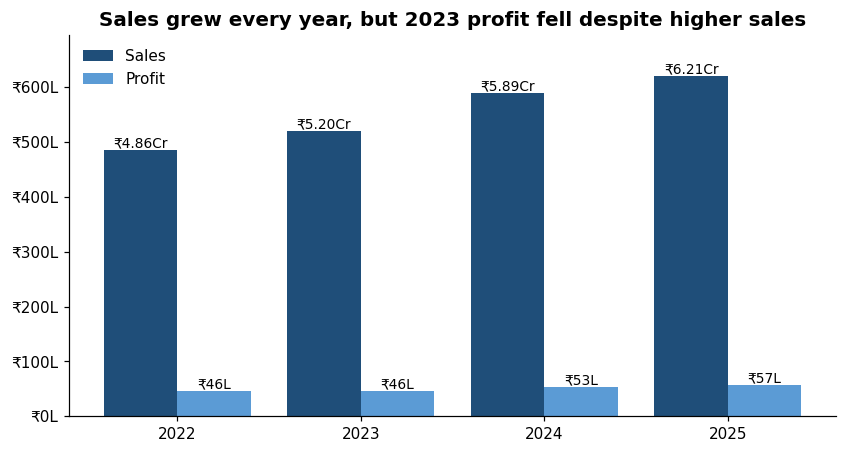

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(yearly))
ax.bar(x - 0.2, yearly["Sales"], 0.4, label="Sales", color=PRIMARY)
ax.bar(x + 0.2, yearly["Profit"], 0.4, label="Profit", color=SECOND)
for i, (s, p) in enumerate(zip(yearly["Sales"], yearly["Profit"])):
    ax.text(i - 0.2, s, f"₹{s/1e7:.2f}Cr", ha="center", va="bottom", fontsize=9)
    ax.text(i + 0.2, p, f"₹{p/1e5:.0f}L", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x, yearly.index)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lakh))
ax.set_title("Sales grew every year, but 2023 profit fell despite higher sales")
ax.legend(frameon=False, loc="upper left")
ax.set_ylim(0, yearly["Sales"].max() * 1.12)
plt.savefig(IMG / "01_yearly_sales_profit.png"); plt.show()

## 4. Monthly trend & seasonality

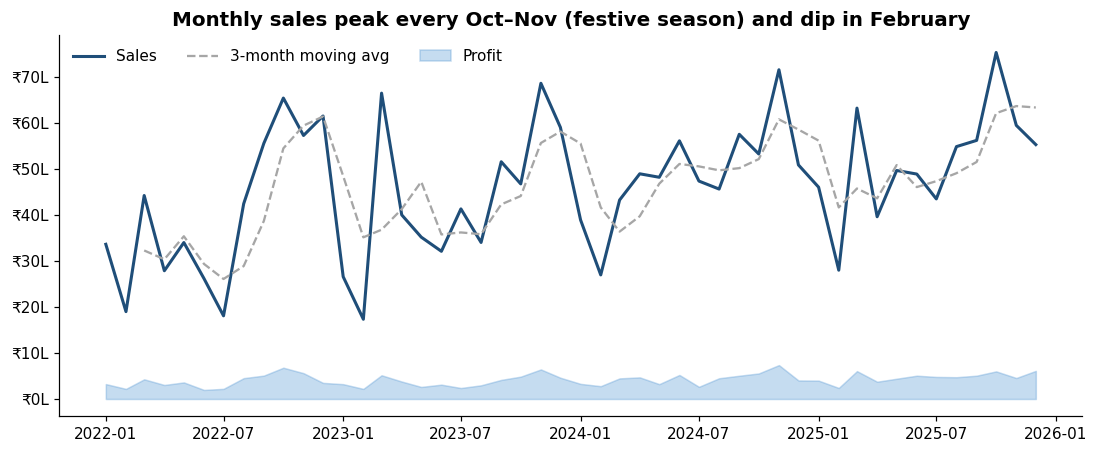

In [7]:
monthly = df.groupby("Year-Month").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
monthly.index = pd.to_datetime(monthly.index)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly["Sales"], color=PRIMARY, lw=2, label="Sales")
ax.plot(monthly.index, monthly["Sales"].rolling(3).mean(), color=GREY, lw=1.5, ls="--", label="3-month moving avg")
ax.fill_between(monthly.index, monthly["Profit"], color=SECOND, alpha=0.35, label="Profit")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lakh))
ax.set_title("Monthly sales peak every Oct–Nov (festive season) and dip in February")
ax.legend(frameon=False, ncol=3)
plt.savefig(IMG / "02_monthly_trend.png"); plt.show()

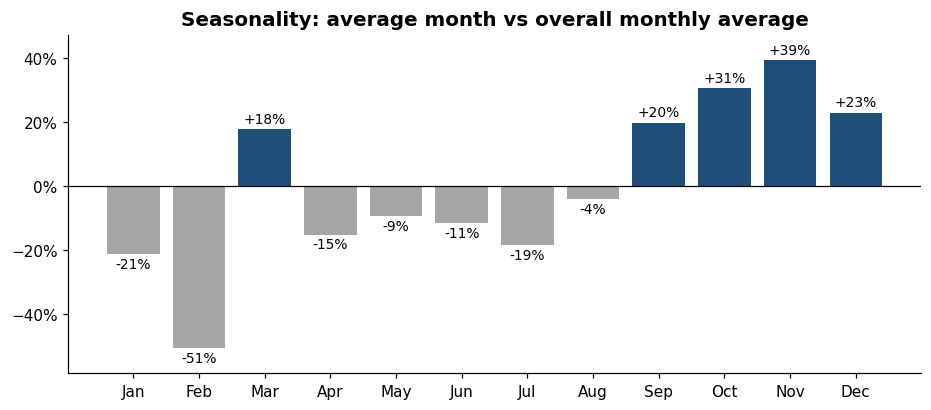

In [8]:
season = (df.groupby(["Order Year", "Order Month"])["Sales"].sum()
            .groupby("Order Month").mean())
season_pct = 100 * season / season.mean() - 100
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PRIMARY if v >= 0 else GREY for v in season_pct]
ax.bar(month_names, season_pct, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Seasonality: average month vs overall monthly average")
for i, v in enumerate(season_pct):
    ax.text(i, v + (1 if v >= 0 else -1), f"{v:+.0f}%", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.set_ylim(season_pct.min() - 8, season_pct.max() + 8)
plt.savefig(IMG / "03_seasonality.png"); plt.show()

## 5. Category & sub-category profitability

In [9]:
cat = df.groupby("Category").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
cat["Margin %"] = 100 * cat["Profit"] / cat["Sales"]
cat["Sales Share %"] = 100 * cat["Sales"] / cat["Sales"].sum()
cat.sort_values("Sales", ascending=False)

,Sales,Profit,Margin %,Sales Share %
Category,,,,
Technology,"149,402,096.71","11,031,026.48",7.38,67.42
Furniture,"51,177,597.93","3,286,289.06",6.42,23.10
Office Supplies,"21,009,006.48","5,821,345.78",27.71,9.48


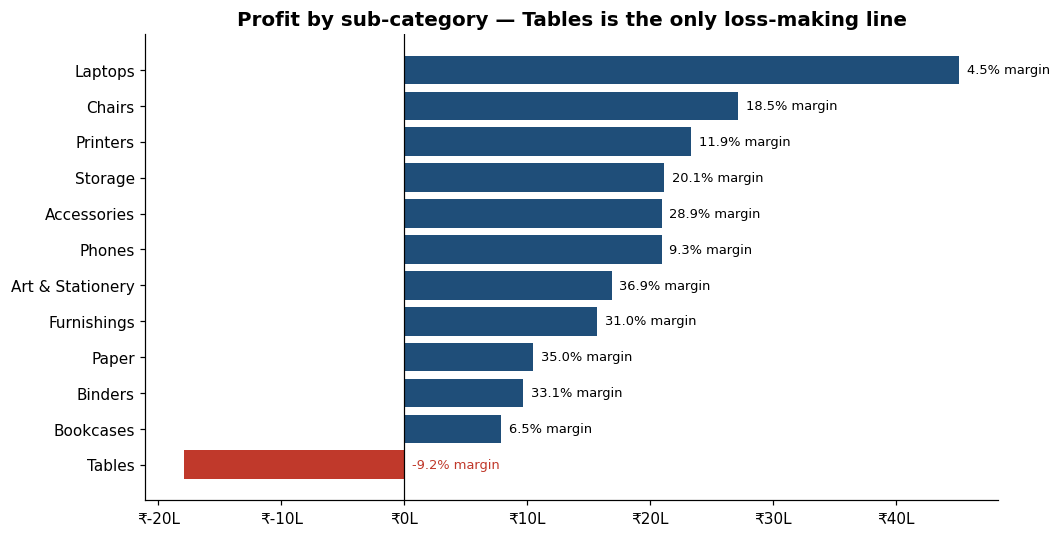

,Category,Sub-Category,Sales,Profit,Avg_Discount,Margin %
0,Technology,Laptops,"99,996,025.65","4,513,310.24",0.08,4.51
1,Furniture,Chairs,"14,668,931.95","2,717,424.11",0.07,18.53
2,Technology,Printers,"19,688,698.51","2,333,150.05",0.07,11.85
3,Office Supplies,Storage,"10,519,949.47","2,115,764.33",0.07,20.11
4,Technology,Accessories,"7,237,829.49","2,092,335.13",0.07,28.91
5,Technology,Phones,"22,479,543.06","2,092,231.06",0.08,9.31
6,Office Supplies,Art & Stationery,"4,570,915.00","1,688,045.49",0.08,36.93
7,Furniture,Furnishings,"5,061,226.24","1,569,861.96",0.07,31.02
8,Office Supplies,Paper,"2,991,091.39","1,048,214.77",0.08,35.04
9,Office Supplies,Binders,"2,927,050.62","969,321.19",0.07,33.12


In [10]:
sub = (df.groupby(["Category", "Sub-Category"])
         .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"), Avg_Discount=("Discount", "mean"))
         .reset_index())
sub["Margin %"] = 100 * sub["Profit"] / sub["Sales"]
sub = sub.sort_values("Profit")

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = [LOSS if p < 0 else PRIMARY for p in sub["Profit"]]
ax.barh(sub["Sub-Category"], sub["Profit"], color=colors)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lakh))
ax.axvline(0, color="black", lw=0.8)
for y, (p, m) in enumerate(zip(sub["Profit"], sub["Margin %"])):
    ax.text(max(p, 0) + 60000, y, f"{m:.1f}% margin", va="center", ha="left", fontsize=8.5,
            color=LOSS if p < 0 else "black")
ax.set_title("Profit by sub-category — Tables is the only loss-making line")
plt.savefig(IMG / "04_subcategory_profit.png"); plt.show()
sub.sort_values("Profit", ascending=False).reset_index(drop=True)

## 6. Regional performance

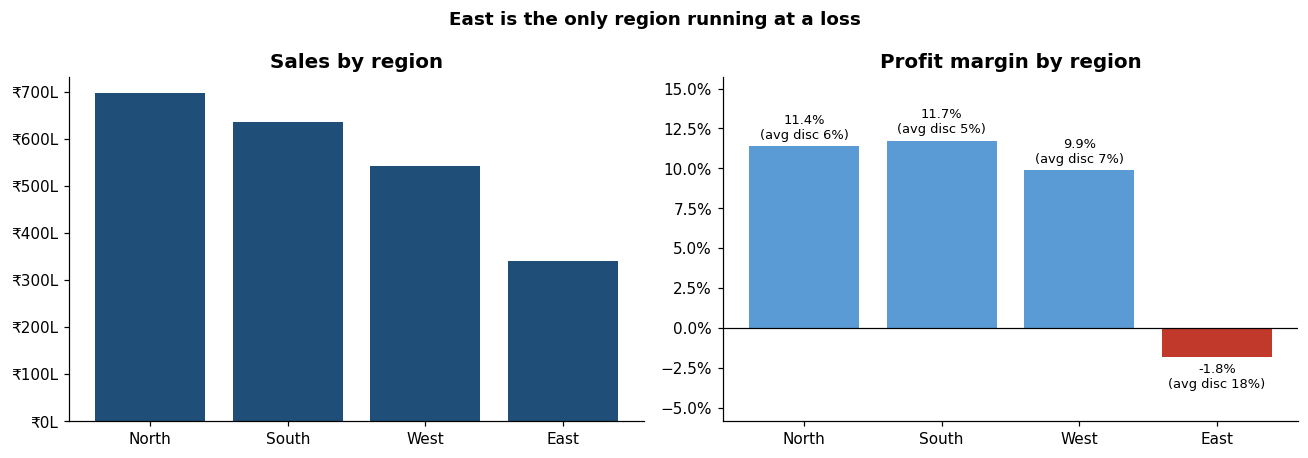

,Sales,Profit,Avg_Discount,Customers,Margin %
Region,,,,,
North,"69,717,567.27","7,939,288.69",6.00,250,11.39
South,"63,651,601.39","7,476,527.67",5.35,234,11.75
West,"54,203,249.93","5,352,119.21",7.42,213,9.87
East,"34,016,282.53","-629,274.25",17.88,119,-1.85


In [11]:
reg = df.groupby("Region").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"),
                               Avg_Discount=("Discount", "mean"), Customers=("Customer ID", "nunique"))
reg["Margin %"] = 100 * reg["Profit"] / reg["Sales"]
reg["Avg_Discount"] *= 100
reg = reg.sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(reg.index, reg["Sales"], color=PRIMARY)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lakh))
axes[0].set_title("Sales by region")
axes[1].bar(reg.index, reg["Margin %"], color=[LOSS if m < 0 else SECOND for m in reg["Margin %"]])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Profit margin by region")
for i, (m, d) in enumerate(zip(reg["Margin %"], reg["Avg_Discount"])):
    axes[1].text(i, m + (0.3 if m >= 0 else -0.3), f"{m:.1f}%\n(avg disc {d:.0f}%)", ha="center",
                 va="bottom" if m >= 0 else "top", fontsize=8.5)
axes[1].set_ylim(reg["Margin %"].min() - 4, reg["Margin %"].max() + 4)
plt.suptitle("East is the only region running at a loss", fontweight="bold")
plt.tight_layout()
plt.savefig(IMG / "05_region_performance.png"); plt.show()
reg

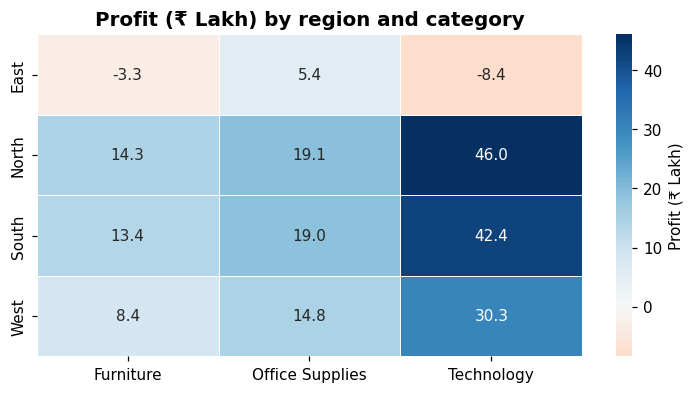

In [12]:
matrix = df.pivot_table(index="Region", columns="Category", values="Profit", aggfunc="sum") / 1e5
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="RdBu", center=0, linewidths=0.5,
            cbar_kws={"label": "Profit (₹ Lakh)"}, ax=ax)
ax.set_title("Profit (₹ Lakh) by region and category")
ax.set_xlabel(""); ax.set_ylabel("")
plt.savefig(IMG / "06_region_category_heatmap.png"); plt.show()

## 7. Discount impact

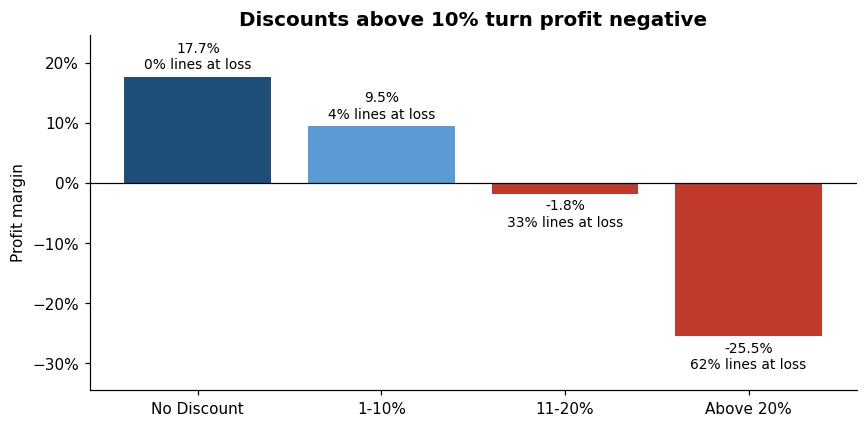

,Lines,Sales,Profit,Loss_Lines,Margin %
Discount Band,,,,,
No Discount,3969,"93,187,848.06","16,466,625.62",0.00,17.67
1-10%,3544,"80,019,221.97","7,583,953.39",4.26,9.48
11-20%,1659,"35,612,442.70","-654,167.89",33.03,-1.84
Above 20%,708,"12,769,188.39","-3,257,749.80",61.72,-25.51


In [13]:
order = ["No Discount", "1-10%", "11-20%", "Above 20%"]
disc = (df.groupby("Discount Band")
          .agg(Lines=("Sales", "size"), Sales=("Sales", "sum"), Profit=("Profit", "sum"),
               Loss_Lines=("Is Loss", "mean"))
          .reindex(order))
disc["Margin %"] = 100 * disc["Profit"] / disc["Sales"]
disc["Loss_Lines"] *= 100

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(disc.index, disc["Margin %"], color=[PRIMARY, SECOND, LOSS, LOSS])
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (m, l) in enumerate(zip(disc["Margin %"], disc["Loss_Lines"])):
    ax.text(i, m + (0.8 if m >= 0 else -0.8), f"{m:.1f}%\n{l:.0f}% lines at loss", ha="center",
            va="bottom" if m >= 0 else "top", fontsize=9)
ax.set_ylim(disc["Margin %"].min() - 9, disc["Margin %"].max() + 7)
ax.set_title("Discounts above 10% turn profit negative")
ax.set_ylabel("Profit margin")
plt.savefig(IMG / "07_discount_impact.png"); plt.show()
disc

In [14]:
# What-if: cap every discount at 20%
gross = df["Sales"] / (1 - df["Discount"])
extra = np.where(df["Discount"] > 0.20, gross * (df["Discount"] - 0.20), 0)
uplift = pd.Series(extra, index=df.index).groupby(df["Region"]).sum()
print(f"Profit uplift if discounts were capped at 20%: ₹{uplift.sum()/1e5:,.2f} Lakh "
      f"(+{100*uplift.sum()/df['Profit'].sum():.1f}% on total profit)")
(uplift / 1e5).round(2).sort_values(ascending=False).to_frame("Uplift (₹ Lakh)")

Profit uplift if discounts were capped at 20%: ₹23.21 Lakh (+11.5% on total profit)


,Uplift (₹ Lakh)
Region,
East,18.94
West,2.94
North,0.91
South,0.41


## 8. Customers & segments

In [15]:
seg = df.groupby("Segment").agg(Customers=("Customer ID", "nunique"), Orders=("Order ID", "nunique"),
                                Sales=("Sales", "sum"), Profit=("Profit", "sum"))
seg["Margin %"] = 100 * seg["Profit"] / seg["Sales"]
seg["AOV (₹)"] = seg["Sales"] / seg["Orders"]
seg.sort_values("Sales", ascending=False)

,Customers,Orders,Sales,Profit,Margin %,AOV (₹)
Segment,,,,,,
Corporate,241,1772,"99,708,681.42","9,042,285.14",9.07,"56,269.01"
Consumer,427,2619,"93,977,913.41","8,781,936.60",9.34,"35,883.13"
Home Office,148,807,"27,902,106.29","2,314,439.58",8.29,"34,575.10"


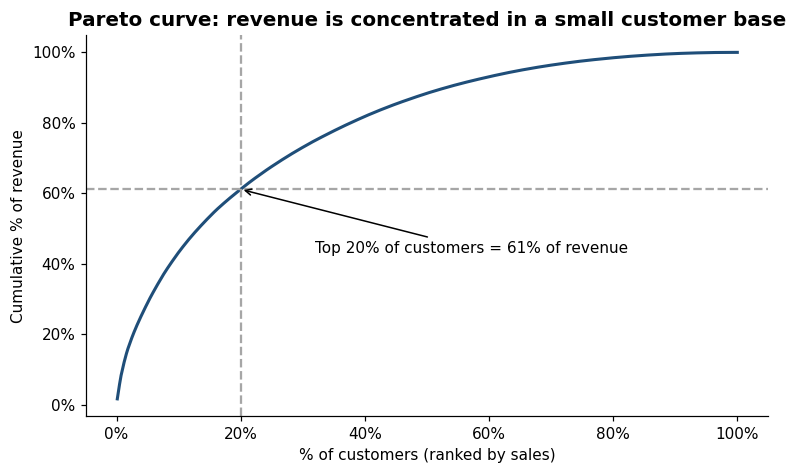

In [16]:
cust = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)
cum_share = 100 * cust.cumsum() / cust.sum()
pct_customers = 100 * np.arange(1, len(cust) + 1) / len(cust)
top20_share = cum_share.iloc[int(len(cust) * 0.2) - 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pct_customers, cum_share, color=PRIMARY, lw=2)
ax.axvline(20, color=GREY, ls="--"); ax.axhline(top20_share, color=GREY, ls="--")
ax.annotate(f"Top 20% of customers = {top20_share:.0f}% of revenue", xy=(20, top20_share),
            xytext=(32, top20_share - 18), arrowprops=dict(arrowstyle="->"), fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of customers (ranked by sales)"); ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Pareto curve: revenue is concentrated in a small customer base")
plt.savefig(IMG / "08_customer_pareto.png"); plt.show()

In [17]:
top_customers = (df.groupby(["Customer ID", "Customer Name", "Segment", "Region"])
                   .agg(Orders=("Order ID", "nunique"), Sales=("Sales", "sum"), Profit=("Profit", "sum"))
                   .sort_values("Sales", ascending=False).head(10).reset_index())
top_customers

,Customer ID,Customer Name,Segment,Region,Orders,Sales,Profit
0,CUST-0421,Shreya Mehta,Corporate,South,86,"3,756,740.26","425,499.17"
1,CUST-0642,Yash Singh,Consumer,West,101,"3,195,431.98","321,525.41"
2,CUST-0468,Varun Joshi,Consumer,East,109,"3,170,596.15","-22,092.48"
3,CUST-0177,Karan Pillai,Corporate,East,62,"2,978,902.93","-133,385.76"
4,CUST-0192,Arjun Bansal,Corporate,North,55,"2,782,491.98","311,337.87"
5,CUST-0016,Manish Kapoor,Corporate,West,47,"2,670,438.28","297,600.94"
6,CUST-0558,Ananya Menon,Corporate,West,33,"2,154,779.34","159,973.01"
7,CUST-0225,Aarav Kapoor,Home Office,North,71,"2,096,853.46","249,943.18"
8,CUST-0740,Simran Kumar,Corporate,South,37,"2,073,060.42","266,530.11"
9,CUST-0588,Yash Das,Consumer,North,47,"1,990,726.10","260,847.15"


## 9. Shipping

In [18]:
ship = df.groupby("Ship Mode").agg(Orders=("Order ID", "nunique"), Avg_Days=("Shipping Days", "mean"))
ship["Share %"] = 100 * ship["Orders"] / ship["Orders"].sum()
ship.sort_values("Orders", ascending=False)

,Orders,Avg_Days,Share %
Ship Mode,,,
Standard Class,3067,5.50,59.00
Second Class,1085,2.99,20.87
First Class,789,2.02,15.18
Same Day,257,0.00,4.94


## 10. Key insights

| # | Insight | Evidence |
|---|---------|----------|
| 1 | **Revenue is growing but profit growth is uneven.** Sales rose every year (₹4.86 Cr in 2022 → ₹6.21 Cr in 2025), yet 2023 profit *fell* 1.2% while sales grew 7.0%. | Section 3 |
| 2 | **Strong festive-season pattern.** November sales run ~39% above an average month and October ~31% above; February is ~50% below. March is also strong (+18%) due to financial-year-end buying. | Section 4 |
| 3 | **Technology drives revenue, Office Supplies drives margin.** Technology is 67% of sales at a 7.4% margin; Office Supplies is only 9.5% of sales but earns a 27.7% margin. | Section 5 |
| 4 | **Tables lose money.** Tables are the only loss-making sub-category (−₹17.9 L, −9.2% margin) with an average discount of 17.5% — more than double every other sub-category. | Section 5 |
| 5 | **East region runs at a loss.** East has a −1.9% margin with an average discount of 17.9%, versus 5–7% in the other regions. | Section 6 |
| 6 | **Discounts above 10% destroy profit.** Lines with 11–20% discount have a −1.8% margin; above 20% the margin is −25.5% and 62% of those lines lose money. | Section 7 |
| 7 | **Capping discounts at 20% would add ≈ ₹23.2 L of profit (+11.5%)**, ₹18.9 L of it from East alone — turning East profitable. | Section 7 |
| 8 | **Revenue is concentrated.** The top 20% of customers generate ~61% of revenue. | Section 8 |

## 11. Recommendations

1. **Introduce a discount approval policy** — cap standard discounts at 20% and require manager approval above 10% for Furniture.
2. **Fix Tables pricing** — review cost price with suppliers or reduce discounting; stop selling tables below cost.
3. **East region turnaround plan** — retrain the East sales team on value selling; track discount % as a weekly KPI.
4. **Plan inventory and marketing around Sep–Dec and March** — the business earns most of its revenue in these months.
5. **Grow high-margin Office Supplies** — bundle stationery and storage with laptop/printer orders for corporate customers.
6. **Protect top customers** — create a key-account programme for the top 20% who bring in ~61% of revenue.